<a href="https://colab.research.google.com/github/neoshield/Aula8_Ecomerce/blob/main/Aula8_Exercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
cust = pd.read_csv('olist_customers_dataset.csv')
geoloc = pd.read_csv('olist_geolocation_dataset.csv')
oitems = pd.read_csv('olist_order_items_dataset.csv')
opay = pd.read_csv('olist_order_payments_dataset.csv')
orev = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
prod_cat_name = pd.read_csv('product_category_name_translation.csv')

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
cost.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [10]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [11]:
oitems.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [12]:
oitems.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [15]:
valorordem = oitems.groupby('order_id')[['price', 'freight_value']].sum().reset_index()
valorordem

,order_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14
...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,43.41
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53
98663,fffce4705a9662cd70adb13d4a31832d,99.90,16.95
98664,fffe18544ffabc95dfada21779c9644f,55.99,8.72


In [16]:
oitems.shape

(112650, 7)

In [17]:
valorordem.shape

(98666, 3)

In [20]:
ordertotprice = orders.merge(valorordem, on='order_id', how='left')
ordertotprice

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,72.00,13.08
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,174.90,20.10
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,205.99,65.02
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,359.98,81.18


In [27]:
ordertotprice["count"] = 1
ordertotprice

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,1
...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,72.00,13.08,1
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,174.90,20.10,1
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,205.99,65.02,1
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,359.98,81.18,1


In [29]:
valorgastocliente = ordertotprice.groupby('customer_id')[['price','count']].sum().reset_index().sort_values(by='price', ascending=False)
valorgastocliente

,customer_id,price,count
8546,1617b1357756262bfa56ab541c47bc16,13440.0,1
91985,ec5b2ba62e574342386871631fafd3fc,7160.0,1
77522,c6e2731c5b391845f6800c97401a43a9,6735.0,1
95124,f48d464a0baaea338cb25f816991ab1f,6729.0,1
24771,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0,1
...,...,...,...
48613,7d61b9f4f216052ba664f22e9c504ef1,0.0,1
84842,d9d61633a0d9de07e5224885bbae0c7a,0.0,1
69656,b2d7ae0415dbbca535b5f7b38056dd1f,0.0,1
17601,2d6272fc5e22facb8937eba512bad93f,0.0,1


In [31]:
valorgastocliente = valorgastocliente[valorgastocliente['price'] > 0]
valorgastocliente

,customer_id,price,count
8546,1617b1357756262bfa56ab541c47bc16,13440.00,1
91985,ec5b2ba62e574342386871631fafd3fc,7160.00,1
77522,c6e2731c5b391845f6800c97401a43a9,6735.00,1
95124,f48d464a0baaea338cb25f816991ab1f,6729.00,1
24771,3fd6777bbce08a352fddd04e4a7cc8f6,6499.00,1
...,...,...,...
82107,d2c63ad286e3ca9dd69218008d61ff81,2.90,1
9456,184e8e8e48937145eb96c721ef1f0747,2.29,1
65095,a790343ca6f3fee08112d678b43aa7c5,2.20,1
8554,161b6d415e8b3413c6609c70cf405b5a,0.85,1


In [37]:
perfcliente = valorgastocliente.merge(cust, on='customer_id', how='left')
perfcliente


,customer_id,price,count,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,1617b1357756262bfa56ab541c47bc16,13440.00,1,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ
1,ec5b2ba62e574342386871631fafd3fc,7160.00,1,763c8b1c9c68a0229c42c9fc6f662b93,29102,vila velha,ES
2,c6e2731c5b391845f6800c97401a43a9,6735.00,1,dc4802a71eae9be1dd28f5d788ceb526,79042,campo grande,MS
3,f48d464a0baaea338cb25f816991ab1f,6729.00,1,459bef486812aa25204be022145caa62,29066,vitoria,ES
4,3fd6777bbce08a352fddd04e4a7cc8f6,6499.00,1,ff4159b92c40ebe40454e3e6a7c35ed6,17506,marilia,SP
...,...,...,...,...,...,...,...
98661,d2c63ad286e3ca9dd69218008d61ff81,2.90,1,728e4a7d0db4845270091ded0923c71f,80540,curitiba,PR
98662,184e8e8e48937145eb96c721ef1f0747,2.29,1,bd06ce0e06ad77a7f681f1a4960a3cc6,4814,sao paulo,SP
98663,a790343ca6f3fee08112d678b43aa7c5,2.20,1,317cfc692e3f86c45c95697c61c853a6,13140,paulinia,SP
98664,161b6d415e8b3413c6609c70cf405b5a,0.85,1,d80730c15c647bc8f2ad77c908ba5ca9,13189,hortolandia,SP


In [43]:
cidmaisrent = perfcliente.groupby("customer_city")["price"].sum().reset_index().sort_values(by='price', ascending=False)
cidmaisrent


,customer_city,price
3588,sao paulo,1914924.54
3147,rio de janeiro,992538.86
452,belo horizonte,355611.13
557,brasilia,301920.25
1141,curitiba,211738.06
...,...,...
1953,jenipapo de minas,7.48
3395,santo antonio do rio abaixo,6.00
3666,senador jose porfirio,6.00
3213,sabaudia,5.90


Os clientes que gastaram mais são de São Paulo

In [39]:
geoloc.columns

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')

In [40]:
perfcliente2 = perfcliente.merge(geoloc, left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix', how='left')
perfcliente2

,customer_id,price,count,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1617b1357756262bfa56ab541c47bc16,13440.00,1,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,20080.0,-22.901095,-43.182559,rio de janeiro,RJ
1,1617b1357756262bfa56ab541c47bc16,13440.00,1,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,20080.0,-22.902817,-43.187022,rio de janeiro,RJ
2,1617b1357756262bfa56ab541c47bc16,13440.00,1,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,20080.0,-22.902256,-43.185562,rio de janeiro,RJ
3,1617b1357756262bfa56ab541c47bc16,13440.00,1,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,20080.0,-22.902817,-43.187022,rio de janeiro,RJ
4,1617b1357756262bfa56ab541c47bc16,13440.00,1,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,20080.0,-22.899655,-43.186841,rio de janeiro,RJ
...,...,...,...,...,...,...,...,...,...,...,...,...
14966170,9f9d249355f63c5c1216a82b802452c1,0.85,1,b38211bd797f4fdd81a98b9d1754b606,25215,duque de caxias,RJ,25215.0,-22.676222,-43.268377,duque de caxias,RJ
14966171,9f9d249355f63c5c1216a82b802452c1,0.85,1,b38211bd797f4fdd81a98b9d1754b606,25215,duque de caxias,RJ,25215.0,-22.688532,-43.269212,duque de caxias,RJ
14966172,9f9d249355f63c5c1216a82b802452c1,0.85,1,b38211bd797f4fdd81a98b9d1754b606,25215,duque de caxias,RJ,25215.0,-22.702811,-43.281186,duque de caxias,RJ
14966173,9f9d249355f63c5c1216a82b802452c1,0.85,1,b38211bd797f4fdd81a98b9d1754b606,25215,duque de caxias,RJ,25215.0,-22.680078,-43.280514,duque de caxias,RJ


In [42]:
perfcliente3 = perfcliente2[perfcliente2["customer_unique_id"] == "0a0a92112bd4c708ca5fde585afaa872"]
perfcliente3

,customer_id,price,count,customer_unique_id,customer_zip_code_prefix,...,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.901095,-43.182559,rio de janeiro,RJ
1,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.902817,-43.187022,rio de janeiro,RJ
2,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.902256,-43.185562,rio de janeiro,RJ
3,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.902817,-43.187022,rio de janeiro,RJ
4,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.899655,-43.186841,rio de janeiro,RJ
...,...,...,...,...,...,...,...,...,...,...,...
63,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.902817,-43.187022,rio de janeiro,RJ
64,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.897149,-43.182621,rio de janeiro,RJ
65,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.901491,-43.183460,rio de janeiro,RJ
66,1617b1357756262bfa56ab541c47bc16,13440.0,1,0a0a92112bd4c708ca5fde585afaa872,20080,...,20080.0,-22.902807,-43.187012,rio de janeiro,RJ


In [46]:
orev2 = orev[pd.notna(orev["review_comment_message"])].sort_values('review_score', ascending=False)
orev2

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99165,80187484a57b26881d1c473fc25c17bf,497382d2dc606112bc69b5cf182f15b6,5,NaN,"Boa tarde, gostei de ter comprado, o material ...",2018-03-06 00:00:00,2018-03-08 15:06:15
99164,2afe63a67dfd99b3038f568fb47ee761,c5334d330e36d2a810a7a13c72e135ee,5,NaN,"Muito bom, produto conforme anunciado, entrega...",2018-03-03 00:00:00,2018-03-04 22:56:47
99162,4e1fad431debcccf54b569356ab41b50,f419e615bbdeb34741d4bdd661ff8599,5,Recomendo,"Recomendo, compra segura entrega correta.",2018-08-17 00:00:00,2018-08-18 12:07:22
99159,c9b98d036008c4acff30e9f81cd639eb,de3bee1ce2ff36750efc09a389ea029e,5,Entrega super Rápida,Super antes do prazo!!!,2018-05-01 00:00:00,2018-05-02 16:07:47
99150,7dd41be728e67dbe34fadb14360fa937,aa962f90c14940f2df3c6184f35a2184,5,Super recomendo,"Produto lindo, entrega rápida e segura.",2018-05-08 00:00:00,2018-05-10 14:04:02
...,...,...,...,...,...,...,...
21197,f48efda92d748b8be3d6d8cb473f7597,f7c983ea77108633138dd0ff5e2fbd3a,1,NaN,O produto deveria ter chegado dia 03/11 mas na...,2017-11-05 00:00:00,2017-11-05 03:03:06
21191,9eb99ee59a9fd2aeec98e6989e505c6d,871586e5b572f8c5d8b07b091e396e6e,1,NaN,O calçado demorou para chegar e já havia sido ...,2017-06-24 00:00:00,2017-06-25 17:17:56
99141,9ed2a6bc2282fd2b0105055631afa57f,a7db1b7bfec5e83a8fd33625e99f0d15,1,NaN,Ate hoje dia 21/10/2017 o pedido não foi entre...,2017-10-21 00:00:00,2017-10-21 18:51:37
68,6d06808638ec0701bccd70bc8d462c28,97d2f8fe76f2f253b8291e17b5383884,1,NaN,O produto não chegou no prazo estipulado e cau...,2016-12-09 00:00:00,2016-12-19 14:10:43


In [54]:
orev ['count'] = 1
orev3 = orev.groupby('review_score')['count'].sum().reset_index()
orev3

,review_score,count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


In [67]:
valorprod = oitems.groupby(['product_id'])[['price']].sum().reset_index().sort_values('price', ascending=False)
valorprod

,product_id,price
24086,bb50f2e236e5eea0100680137654686c,63885.00
14068,6cdd53843498f92890544667809f1595,54730.20
27613,d6160fb7873f184099d9bc95e30376af,48899.34
27039,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
19742,99a4788cb24856965c36a24e339b6058,43025.56
...,...,...
6086,2e8316b31db34314f393806fd7b6e185,2.99
13461,680cc8535be7cc69544238c1d6a83fe8,2.90
17767,8a3254bee785a526d548a81a9bc3c9be,2.55
6388,310dc32058903b6416c71faff132df9e,2.29


In [70]:
prods = valorprod.merge(products, on = "product_id")
prods

,product_id,price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,bb50f2e236e5eea0100680137654686c,63885.00,beleza_saude,60.0,2644.0,6.0,400.0,34.0,4.0,22.0
1,6cdd53843498f92890544667809f1595,54730.20,beleza_saude,51.0,625.0,1.0,900.0,25.0,12.0,38.0
2,d6160fb7873f184099d9bc95e30376af,48899.34,pcs,55.0,3632.0,4.0,2600.0,16.0,31.0,39.0
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0
4,99a4788cb24856965c36a24e339b6058,43025.56,cama_mesa_banho,54.0,245.0,1.0,1383.0,50.0,10.0,40.0
...,...,...,...,...,...,...,...,...,...,...
32946,2e8316b31db34314f393806fd7b6e185,2.99,papelaria,55.0,88.0,1.0,100.0,16.0,10.0,16.0
32947,680cc8535be7cc69544238c1d6a83fe8,2.90,pet_shop,48.0,1392.0,1.0,200.0,16.0,2.0,11.0
32948,8a3254bee785a526d548a81a9bc3c9be,2.55,construcao_ferramentas_construcao,25.0,1041.0,5.0,200.0,16.0,4.0,11.0
32949,310dc32058903b6416c71faff132df9e,2.29,papelaria,36.0,326.0,1.0,300.0,16.0,10.0,11.0


In [72]:
catsales = prods.groupby("product_category_name")["price"].sum().reset_index().sort_values('price', ascending=False)
catsales

,product_category_name,price
11,beleza_saude,1258681.34
66,relogios_presentes,1205005.68
13,cama_mesa_banho,1036988.68
32,esporte_lazer,988048.97
44,informatica_acessorios,911954.32
...,...,...
41,flores,1110.04
15,casa_conforto_2,760.27
17,cds_dvds_musicais,730.00
37,fashion_roupa_infanto_juvenil,569.85


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

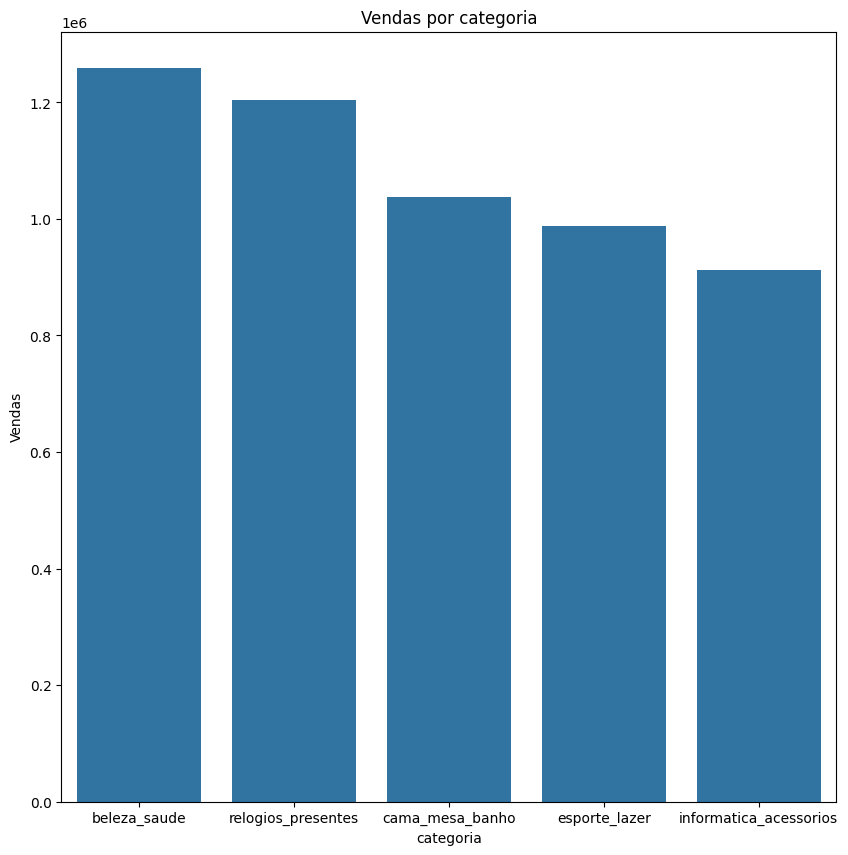

In [78]:
catsalestop = catsales.head(5)

plt.figure(figsize=(10,10))

sns.barplot(x="product_category_name", y="price", data=catsalestop)

#plt.plot(df["clientes"], df["vendas"])

plt.title("Vendas por categoria")

# titulo do gráfico
plt.xlabel("categoria")

# Nome do eixo X
plt.ylabel("Vendas")

# Nome do eixo Y

plt.show()